In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import logging
import re
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple
from dataclasses import replace

import numpy as np
from scipy.special import logsumexp

from config import Case1Config
from metabias.fht.gaussian import FunctionalHierarchicalTensorGaussian
from metabias.fht.sketch_gaussian import hier_tensor_sketch_gaussian


: 

In [ ]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
data = np.loadtxt("./run1/COLVAR")
H,xedges,yedges= np.histogram2d(data[:,1],data[:,2],bins=np.linspace(-np.pi,np.pi,100),density=True);
plt.contourf(xedges[:-1],yedges[:-1],np.log(H.T)* kB * T)
plt.colorbar()

: 

In [ ]:
plt.plot(data[::10,1],".")

: 

In [ ]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
data = np.loadtxt("./run2/COLVAR")
H,xedges,yedges= np.histogram2d(data[:,1],data[:,2],bins=np.linspace(-np.pi,np.pi,100),density=True,weights=np.exp(-kB * T *data[:,-2] ));
plt.contourf(xedges[:-1],yedges[:-1],np.log(H.T)* kB * T)
plt.colorbar()

: 

In [ ]:
plt.plot(data[::10,1],".")

: 

In [ ]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
data = np.loadtxt("./run3/COLVAR")
H,xedges,yedges= np.histogram2d(data[:,1],data[:,2],bins=np.linspace(-np.pi,np.pi,100),density=True,weights=np.exp(-kB * T *data[:,-2] ));
plt.plot(data[::100,1],data[::100,2],".")
plt.contourf(xedges[:-1],yedges[:-1],np.log(H.T)* kB * T)
plt.colorbar()

: 

In [ ]:
plt.plot(data[:,1],".")

: 

In [ ]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
data = np.loadtxt("./run4/COLVAR")
H,xedges,yedges= np.histogram2d(data[:,1],data[:,2],bins=np.linspace(-np.pi,np.pi,100),density=True,weights=np.exp(-kB * T *data[:,-2] ));
plt.contourf(xedges[:-1],yedges[:-1],np.log(H.T)* kB * T)
plt.colorbar()

: 

In [ ]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
data = np.loadtxt("./run5/COLVAR")
H,xedges,yedges= np.histogram2d(data[:,1],data[:,2],bins=np.linspace(-np.pi,np.pi,100),density=True,weights=np.exp(-kB * T *data[:,-2] ));
plt.contourf(xedges[:-1],yedges[:-1],np.log(H.T)* kB * T)
plt.colorbar()

: 

In [ ]:
kB = 8.314462618e-3  # kJ/(mol*K)
T = 300.0
data = np.loadtxt("./run6/COLVAR")
H,xedges,yedges= np.histogram2d(data[:,1],data[:,2],bins=np.linspace(-np.pi,np.pi,100),density=True,weights=np.exp(-kB * T *data[:,-2] ));
plt.contourf(xedges[:-1],yedges[:-1],np.log(H.T)* kB * T)
plt.colorbar()

: 

In [ ]:

cfg = Case1Config()

# 你的 fallback 这里建议用 gaussian_center_spacing，不是 cfg.center_spacing
default_spacing = cfg.gaussian_center_spacing
if default_spacing is None:
    default_spacing = 2.0 / (2 * cfg.deg + 1)

obj = np.load("../case4/run10/c_save.npz", allow_pickle=True)
c = obj["c"].item()
model_sigma = float(np.array(obj["gaussian_sigma"]).reshape(())) if "gaussian_sigma" in obj.files else float(cfg.gaussian_sigma)
model_center_spacing = (
    float(np.array(obj["gaussian_center_spacing"]).reshape(()))
    if "gaussian_center_spacing" in obj.files
    else float(default_spacing)
)

htn = FunctionalHierarchicalTensorGaussian(
    d=cfg.d,
    L=cfg.L,
    deg=cfg.deg,
    c=c,
    ghost_pt=[],
    sigma=model_sigma,
    center_spacing=model_center_spacing,
    domain=cfg.gaussian_domain,
    pbc=cfg.gaussian_pbc,
    whiten=cfg.gaussian_whiten,
    whitening_regularization=cfg.gaussian_whitening_regularization,
    normalize=True,
)

def softplus(x):
    return np.where(x > 50.0, x, np.log1p(np.exp(x)))

# grid in normalized CV space [-1,1]
n = 220
x = np.linspace(-1.0, 1.0, n)
y = np.linspace(-1.0, 1.0, n)
X, Y = np.meshgrid(x, y, indexing="xy")
S = np.column_stack([X.ravel(), Y.ravel()])

rho = htn.evaluate(S).reshape(n, n)
rho = np.where(np.isfinite(rho), rho, 0.0)
tau = cfg.tau_factor * cfg.eps
rho_eff = cfg.eps + tau * softplus((rho ) / tau)

# bias = -kBT * alpha * log(rho_eff)
T = 300.0  # 改成你的模拟温度
kBT = 8.31446261815324e-3 * T  # kJ/mol
Vbias = -kBT * cfg.alpha * np.log(rho_eff)
Vbias -= np.nanmin(Vbias)  # 平移到最小值=0，便于看图

plt.figure(figsize=(5.6, 4.6))
cf = plt.contourf(X * np.pi, Y * np.pi, rho_eff, levels=40, cmap="viridis")
plt.colorbar(cf, label="Bias potential (kJ/mol)")
plt.xlabel("phi1 (rad)")
plt.ylabel("psi1 (rad)")
plt.tight_layout()
plt.show()


: 

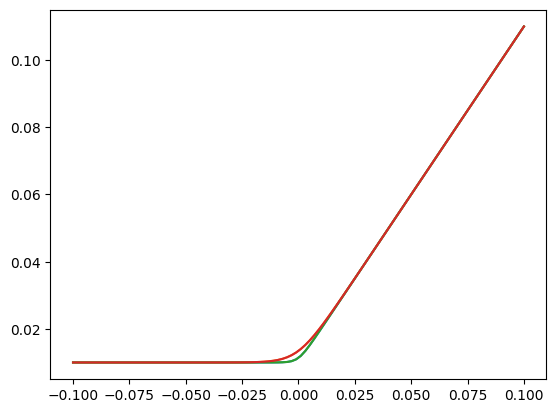

In [12]:
eps = 1e-2
tau = 0.2*eps
x  = np.linspace(-0.1,0.1,100)
y = eps + tau * softplus((x ) / tau)
plt.plot(x,y)
tau = 0.5*eps
x  = np.linspace(-0.1,0.1,100)
y = eps + tau * softplus((x ) / tau)
plt.plot(x,y)
eps = 1e-2
tau = 0.2*eps
x  = np.linspace(-0.1,0.1,100)
y = eps + tau * softplus((x ) / tau)
plt.plot(x,y)
tau = 0.5*eps
x  = np.linspace(-0.1,0.1,100)
y = eps + tau * softplus((x ) / tau)
plt.plot(x,y)